# Visión por Computadora II - Trabajo Final

## Integrantes

- Acevedo Zain, Gaspar (acevedo.zain.gaspar@gmail.com)
- Lauro, Rodrigo (ing.rodrigo.lauro@gmail.com)
- Rodrigues da Cruz, Nicolás (Nicolasrdc151@gmail.com)

## Descripción del problema

- Tipo de problema: Clasificación
- Descripción: Detección de nódulos pulmonares en tomografías de tórax.
- Detalles: Desarrollar un modelo de aprendizaje profundo que identifique la presencia de nódulos pulmonares en imágenes de tomografía computarizada (CT) de tórax.​
- Dataset: [Chest CT-Scan images Dataset](https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images)

## Imports

In [1]:
import torchvision
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import torch
import cv2

import numpy as np
import pandas as pd

import os
from zipfile import ZipFile
from typing import Tuple
import math
import random

import matplotlib.pyplot as plt
from collections import Counter

from sklearn.decomposition import PCA

## Descarga del dataset

In [2]:
!curl -L -o "/content/dataset.zip" "https://www.kaggle.com/api/v1/datasets/download/mohamedhanyyy/chest-ctscan-images"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  118M  100  118M    0     0  89.8M      0  0:00:01  0:00:01 --:--:-- 88.8M


In [3]:
zip_file = "/content/dataset.zip"
dataset_unzip_folder = "/content/."
dataset_folder = "/content/Data"
DATASET_TRAIN = os.path.join(dataset_folder, "train")
DATASET_TEST = os.path.join(dataset_folder, "test")
DATASET_VALID = os.path.join(dataset_folder, "valid")

In [4]:
# Descomprimo si NO existe la carpeta /content/dataset_emociones
if not os.path.isdir(dataset_folder):
  with ZipFile(zip_file, 'r') as zip_object:
    zip_object.extractall(path=dataset_unzip_folder)

## EDA


Primero definimos una transformación básica en donde se aplica la transformación [ToTensor](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.ToTensor.html).

Esta permite convertir una imagen en un *tensor*, lo cual es necesario para trabajar con algunos modelos de PyTorch. También permite escalar los valores de píxeles originales (rango $[0; 255]$) al rango $[0; 1]$.

Por el momento solo se aplica esta transformación, ya que deseamos hacer un análisis inicial del dataset, pero en pasos posteriores se agregarán otras transformaciones según sea conveniente.



In [5]:
basic_transform = transforms.Compose([
    transforms.ToTensor(),
])

Se crean los datasets de `train`, `test` y `validation` utilizando la clase [ImageFolder](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html).

En cada uno se aplica la transformación base definida en `basic_transform`.

In [6]:
train_data = datasets.ImageFolder(root=DATASET_TRAIN, transform=basic_transform)
test_data = datasets.ImageFolder(root=DATASET_TEST, transform=basic_transform)
validation_data = datasets.ImageFolder(root=DATASET_VALID, transform=basic_transform)

En cada dataset se tienen las siguientes cantidades de imágenes:

- `Train`: $613$
- `Test`: $315$
- `Validation`: $72$

In [7]:
print(f"Cantidad de imágenes en Train: {len(train_data)}")
print(f"Cantidad de imágenes en Test: {len(test_data)}")
print(f"Cantidad de imágenes en Validation: {len(validation_data)}")

Cantidad de imágenes en Train: 613
Cantidad de imágenes en Test: 315
Cantidad de imágenes en Validation: 72


A continuación se definen las siguientes funciones:

- `get_class_counts`: dado un dataset formado mediante un `ImageFolder`, devuelve una lista con el nombre de las clases y otra con la cantidad de ocurrencias de cada una.
- `plot_image_class_distribution`: realiza un gráfico de cantidad de ocurrencias de cada clase en un dataset formado por `ImageFolder`.

In [8]:
def get_class_counts(dataset: ImageFolder) -> Tuple[list, list]:
  """
  Dado un dataset de tipo ImageFolder, devuelve las clases y
  su cantidad de ocurrencias.

  Args:
    dataset (ImageFolder): Dataset sobre el cual se obtendrán las
      clases y sus cantidades de ocurrencias.
  Returns:
    Tuple[list, list]: Devuelve dos listas:
      class_names: nombre de clases del dataset.
      counts: cantidad de ocurrencia de cada clase en el dataset.
  """
  class_labels = dataset.targets
  class_counts = Counter(class_labels)
  class_names = train_data.classes
  counts = [class_counts[i] for i in range(len(class_names))]

  return class_names, counts

In [9]:
def plot_image_class_distribution(dataset: ImageFolder,
                                  datasetName: str = "train",
                                  figsize: tuple = (10, 6)):
  """
  Grafica la distribución de clases de un dataset de imágenes.

  Args:
    dataset (ImageFolder): dataset cuyas clases se graficarán.
    datasetName (str): nombre del dataset, que se utilizará para el título
      del gráfico.
    figsize (tuple): tamaño del gráfico. Por defecto es (10, 6).
  """
  class_names, counts = get_class_counts(dataset=dataset)

  plt.figure(figsize=figsize)
  plt.barh(class_names, counts)
  plt.xlabel("Cantidad de imágenes")
  plt.ylabel("Clases")
  plt.title(f"Distribución de imágenes por clases en dataset {datasetName}")
  plt.tight_layout()
  plt.show()

### Distribuciones de clases en cada dataset

El dataset de train tiene la siguiente distribución de clases:

| Clase | Cantidad |
| --- | --- |
| `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` | $195$ |
| `large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa` | $115$ |
| `normal` | $148$ |
| `squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa` | $155$ |

Es decir, el dataset de `train` presenta un ligero desbalance de clases, siendo `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` la que mayor ocurrencias tiene, y `large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa` las que menos tiene.

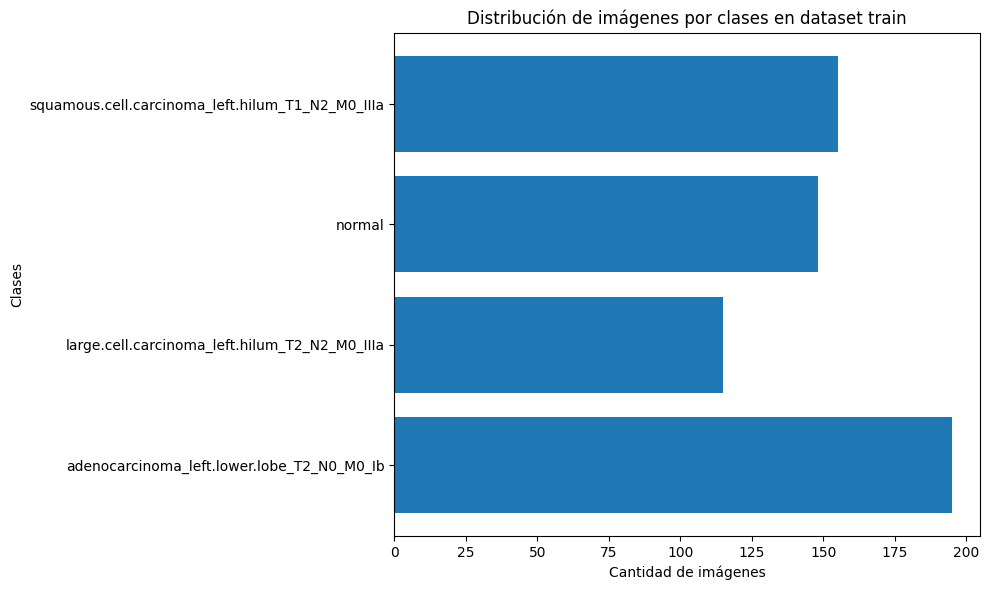

In [10]:
plot_image_class_distribution(dataset=train_data, datasetName="train")

El dataset de `test` tiene la siguiente distribución de clases:

| Clase | Cantidad |
| --- | --- |
| `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` | $120$ |
| `large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa` | $51$ |
| `normal` | $54$ |
| `squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa` | $90$ |

Es decir, el dataset de `test` presenta ligero desbalance de clases, siendo `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` la que mayor ocurrencias tiene.

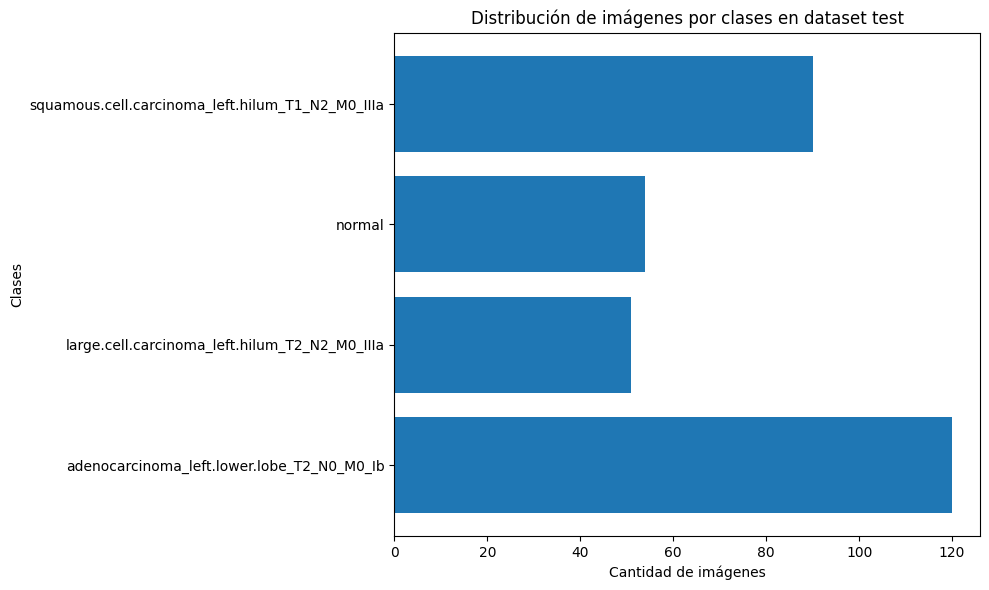

In [11]:
plot_image_class_distribution(dataset=test_data, datasetName="test")

El dataset de `validation` tiene la siguiente distribución de clases:

| Clase | Cantidad |
| --- | --- |
| `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` | $23$ |
| `large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa` | $21$ |
| `normal` | $13$ |
| `squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa` | $15$ |

Es decir, este dataset está ligeramente desbalanceado.

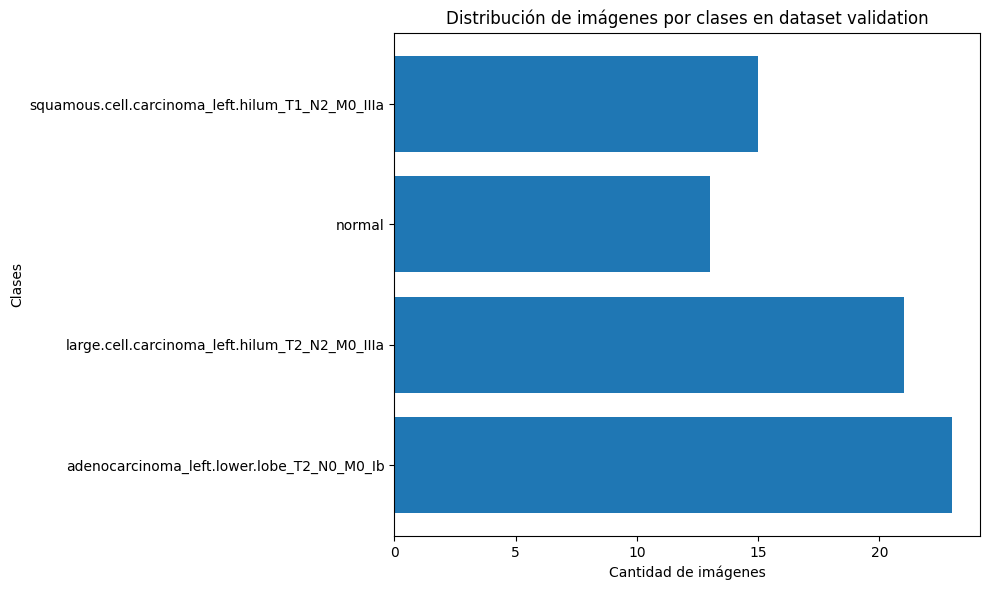

In [12]:
plot_image_class_distribution(dataset=validation_data, datasetName="validation")

### Análisis de dimensiones

En esta sección se analizan las dimensiones de las imágenes de los datasets de `train`, `test` y `validation`.

Comenzamos definiendo la función `get_shape_counts`, la cual devuelve las dimensiones de las imágenes de un dataset, como así también el *conteo* de sus ocurrencias.

Esto permitirá tener un primer acercamiento a las dimensiones de las imágenes de los datasets, que nos permitirá si todas tienen el mismo tamaño o no.

In [13]:
def get_shape_counts(dataset: ImageFolder) -> Counter:
  """
  Dado un dataset de tipo ImageFolder, devuelve las dimensiones de
  sus imágenes, junto la cantidad de ocurrencias.

  Args:
    dataset (ImageFolder): Dataset sobre el cual se obtendrán las
      clases y sus cantidades de ocurrencias.
  Returns:
    Counter: contador de ocurrencias de cada dimensión de imágen
    distinta en el dataset.
  """
  dataset_shapes = []

  for img in dataset:
    dataset_shapes.append(img[0].shape)

  dataset_counts = Counter(dataset_shapes)

  return dataset_counts

In [14]:
train_data_shape = get_shape_counts(dataset=train_data)
test_data_shape = get_shape_counts(dataset=test_data)
validation_data_shape = get_shape_counts(dataset=validation_data)

Para el dataset de `train` se observa que la mayoría de las imágenes tienen dimensiones distintas.

Solamente coinciden en la cantidad de canales ($3$ o `RGB`).

In [15]:
train_data_shape

Counter({torch.Size([3, 264, 409]): 1,
         torch.Size([3, 243, 397]): 1,
         torch.Size([3, 244, 392]): 1,
         torch.Size([3, 220, 377]): 1,
         torch.Size([3, 272, 373]): 1,
         torch.Size([3, 288, 449]): 1,
         torch.Size([3, 276, 389]): 1,
         torch.Size([3, 328, 384]): 1,
         torch.Size([3, 323, 417]): 1,
         torch.Size([3, 247, 341]): 1,
         torch.Size([3, 232, 386]): 1,
         torch.Size([3, 246, 410]): 1,
         torch.Size([3, 250, 390]): 1,
         torch.Size([3, 274, 414]): 1,
         torch.Size([3, 242, 423]): 1,
         torch.Size([3, 269, 419]): 1,
         torch.Size([3, 259, 429]): 1,
         torch.Size([3, 211, 373]): 1,
         torch.Size([3, 305, 413]): 1,
         torch.Size([3, 286, 413]): 1,
         torch.Size([3, 258, 387]): 1,
         torch.Size([3, 284, 377]): 1,
         torch.Size([3, 206, 432]): 1,
         torch.Size([3, 295, 391]): 1,
         torch.Size([3, 296, 396]): 1,
         torch.Size([3, 2

Para el dataset de `test` se observa lo mismo que en el dataset anterior: la mayoría de las imágenes tienen dimensiones distintas.

Solamente coinciden en la cantidad de canales ($3$ o `RGB`).

In [16]:
test_data_shape

Counter({torch.Size([3, 282, 381]): 1,
         torch.Size([3, 335, 486]): 1,
         torch.Size([3, 357, 483]): 1,
         torch.Size([3, 406, 456]): 1,
         torch.Size([3, 328, 464]): 1,
         torch.Size([3, 340, 485]): 1,
         torch.Size([3, 309, 379]): 1,
         torch.Size([3, 260, 439]): 1,
         torch.Size([3, 389, 460]): 1,
         torch.Size([3, 320, 444]): 1,
         torch.Size([3, 264, 484]): 1,
         torch.Size([3, 356, 454]): 1,
         torch.Size([3, 326, 465]): 1,
         torch.Size([3, 364, 406]): 1,
         torch.Size([3, 318, 453]): 1,
         torch.Size([3, 280, 409]): 1,
         torch.Size([3, 271, 400]): 1,
         torch.Size([3, 409, 468]): 1,
         torch.Size([3, 365, 422]): 1,
         torch.Size([3, 340, 443]): 1,
         torch.Size([3, 397, 475]): 1,
         torch.Size([3, 342, 456]): 1,
         torch.Size([3, 322, 456]): 1,
         torch.Size([3, 314, 429]): 1,
         torch.Size([3, 347, 454]): 1,
         torch.Size([3, 2

Para el dataset de `validation` sucede lo mismo que en los datasets anteriores.

In [17]:
validation_data_shape

Counter({torch.Size([3, 245, 315]): 1,
         torch.Size([3, 247, 395]): 1,
         torch.Size([3, 264, 439]): 1,
         torch.Size([3, 335, 424]): 1,
         torch.Size([3, 256, 406]): 1,
         torch.Size([3, 219, 381]): 1,
         torch.Size([3, 275, 394]): 1,
         torch.Size([3, 251, 377]): 1,
         torch.Size([3, 269, 338]): 1,
         torch.Size([3, 245, 431]): 1,
         torch.Size([3, 182, 374]): 1,
         torch.Size([3, 253, 358]): 1,
         torch.Size([3, 202, 361]): 1,
         torch.Size([3, 252, 359]): 1,
         torch.Size([3, 249, 408]): 1,
         torch.Size([3, 258, 356]): 1,
         torch.Size([3, 192, 345]): 1,
         torch.Size([3, 246, 421]): 1,
         torch.Size([3, 299, 379]): 1,
         torch.Size([3, 274, 409]): 1,
         torch.Size([3, 216, 353]): 1,
         torch.Size([3, 242, 408]): 1,
         torch.Size([3, 235, 388]): 1,
         torch.Size([3, 205, 386]): 1,
         torch.Size([3, 274, 353]): 1,
         torch.Size([3, 2

Para determinar cuales son los valores mínimos y máximos del ancho (width) y altura (height) de cada dataset, se crea primero la función `get_min_max_dimensions`.

Luego, se procesó cada dataset con dicha función, obteniendo los siguientes resultados:

| Dataset | Min. Height | Max. Height | Min. Width | Max. Width |
| --- | --- | --- | --- | --- |
| `Train` | $168$ | $1200$ | $110$ | $874$ |
| `Test` | $360$ | $940$ | $232$ | $700$ |
| `Validation` | $315$ | $940$ | $181$ | $627$ |

In [18]:
def get_min_max_dimensions(dataset: ImageFolder) -> Tuple[int, int, int, int]:
  """
  Devuelve las dimensiones máximas y mínimas de un dataset de imágenes:

  Args:
    dataset (ImageFolder): dataset cuyas imágenes serán analizadas.
  Returns:
    Tuple[int, int, int, int]: min_height, max_height, min_width, max_width.
  """
  widths = [d[0].shape[1] for d in dataset]
  heights = [d[0].shape[2] for d in dataset]

  return min(heights), max(heights), min(widths), max(widths)

In [19]:
min_height, max_height, min_width, max_width = get_min_max_dimensions(dataset=train_data)
print(f"Dimensiones del dataset de TRAIN:\n\tmin_height: {min_height}\n\tmax_height: {max_height}\n\tmin_width: {min_width}\n\tmax_width: {max_width}")

Dimensiones del dataset de TRAIN:
	min_height: 168
	max_height: 1200
	min_width: 110
	max_width: 874


In [20]:
min_height, max_height, min_width, max_width = get_min_max_dimensions(dataset=test_data)
print(f"Dimensiones del dataset de TEST:\n\tmin_height: {min_height}\n\tmax_height: {max_height}\n\tmin_width: {min_width}\n\tmax_width: {max_width}")

Dimensiones del dataset de TEST:
	min_height: 360
	max_height: 940
	min_width: 232
	max_width: 700


In [21]:
min_height, max_height, min_width, max_width = get_min_max_dimensions(dataset=validation_data)
print(f"Dimensiones del dataset de VALIDATION:\n\tmin_height: {min_height}\n\tmax_height: {max_height}\n\tmin_width: {min_width}\n\tmax_width: {max_width}")

Dimensiones del dataset de VALIDATION:
	min_height: 315
	max_height: 940
	min_width: 181
	max_width: 627


***Conclusión***

Los tres datasets presentan imágenes de distintas dimensiones, lo cual puede llegar a ser perjudicial en el procesamiento de las mismas, ya que al trabajar con [Dataloader](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) las imágenes deben tener las mismas ***dimensiones***.

Por este motivo será necesario aplicar una ***transformación de dimensiones*** en los datasets mediante la función [Resize](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Resize.html).

### Visualización de imágenes

Con el fin de analizar las imágenes de los distintos datasets, comenzamos primero redefiniendo las transformaciones a aplicar.

En particular, se agrega la transformación [Resize](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Resize.html), la cual permite redimensionar las imágenes en un *ancho* y *alto* determinados.

En este caso, a fin de hacer una primer aproximación a las imágenes, se opta por redimensionar a $128 x 128$.

Posteriormente se analizará si esta dimensión es la ideal o no.

In [22]:
basic_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [23]:
train_data = datasets.ImageFolder(root=DATASET_TRAIN, transform=basic_transform)
test_data = datasets.ImageFolder(root=DATASET_TEST, transform=basic_transform)
validation_data = datasets.ImageFolder(root=DATASET_VALID, transform=basic_transform)

A continuación se crean los [DataLoader](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) de cada dataset, que serán útiles para la carga de imágenes y su posterior procesamiento.

In [24]:
BATCH_SIZE = 32

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE)

In [25]:
def show_images_from_loader(dataloader: DataLoader, figsize: tuple = (10, 10),
                            rows: int = 5, nrow: int = 5):
  """
  Muestra N imágenes de un dataloader.

  Args:
    dataloader (DataLoader): dataloader con las imágenes a mostrar.
    figsize (tuple): Tupla que indica el tamaño de la imagen resultante.
    rows (int): Cantidad de filas a mostrar en la imagen resultante.
    nrow (int): Cantidad de imágenes por filas.
  Raise:
    ValueError: si el product de nrow y row es mayor al batch_size del dataloader.
  """
  if (rows * nrow) > dataloader.batch_size:
    raise ValueError(f"El producto de rows y nrows ({rows} * {nrow}) debe ser menor o igual a batch_size del dataloader ({dataloader.batch_size}).")

  dataiter = iter(dataloader)
  images, labels = next(dataiter)

  plt.figure(figsize=figsize)
  plt.imshow(np.transpose(torchvision.utils.make_grid(
      images[:rows * nrow], nrow=nrow).numpy(), (1, 2, 0)))
  plt.axis('off')
  plt.show()

Se muestran a continuación las primeras $25$ imágenes del dataset de `train`:

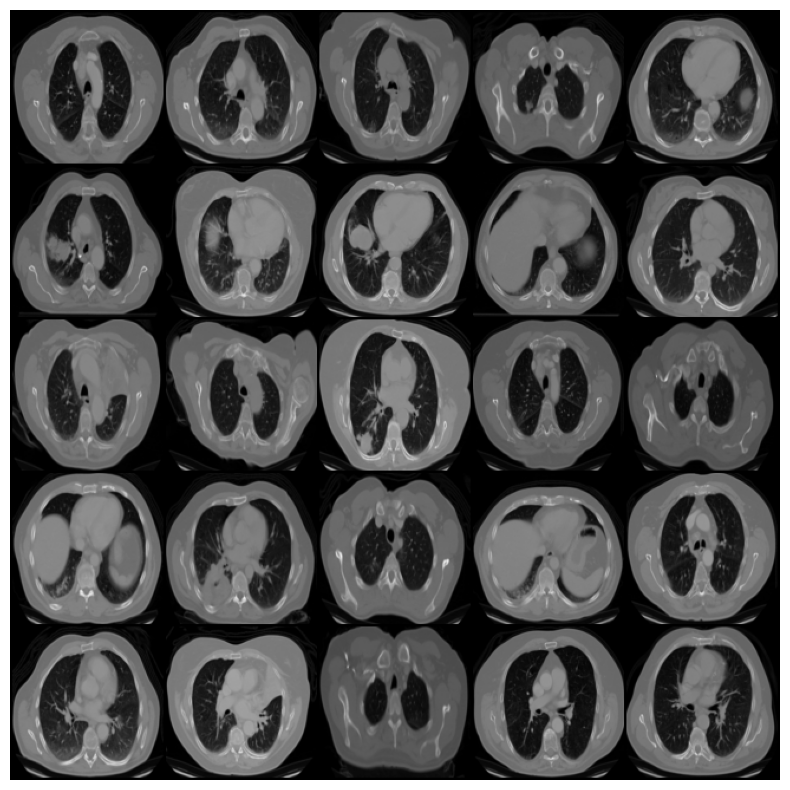

In [26]:
show_images_from_loader(dataloader=train_loader)

Se muestran a continuación las primeras $25$ imágenes del dataset de `test`:

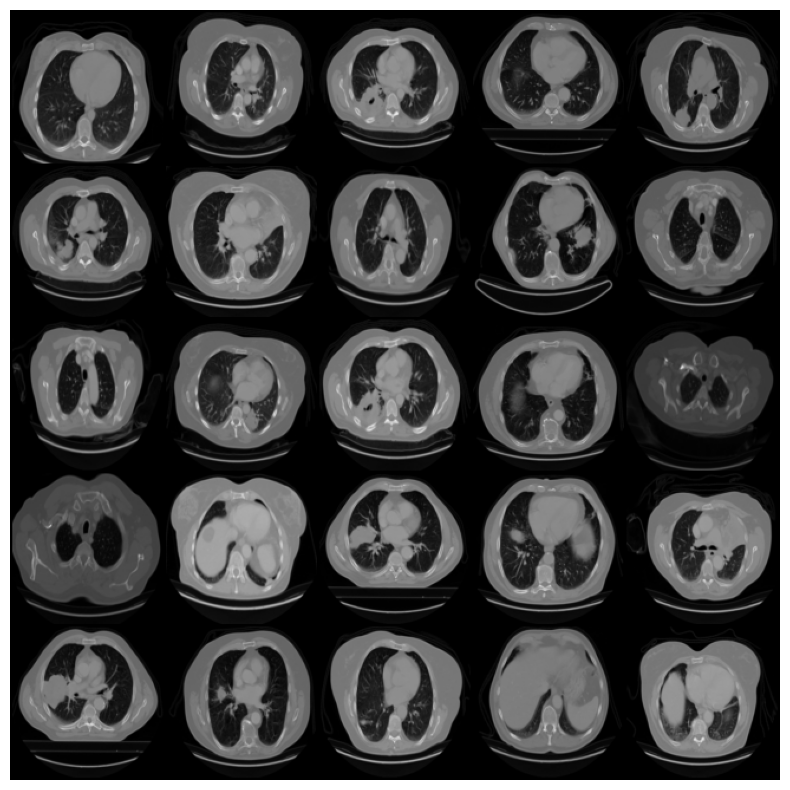

In [27]:
show_images_from_loader(dataloader=test_loader)

Se muestran a continuación las primeras $25$ imágenes del dataset de `validation`:

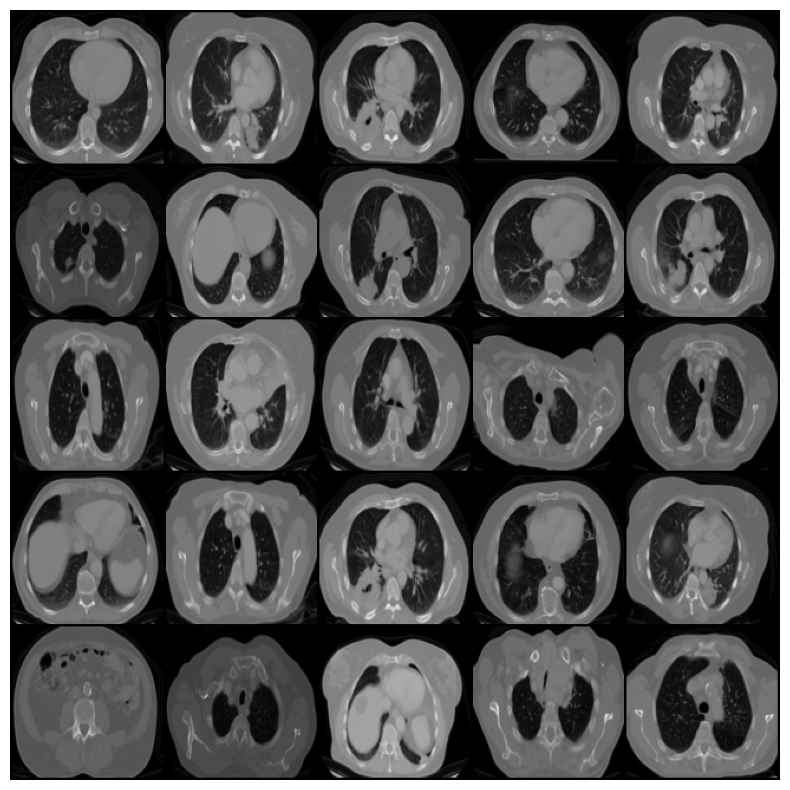

In [28]:
show_images_from_loader(dataloader=validation_loader)

***Conclusiones***

Si bien no es una conclusión final, un preprocesamiento/transformación que vale la pena estudiar es [Grayscale](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Grayscale.html), la cual convierte las imágenes en escala de grises.

Esto también beneficia que las imágenes tienen una vez procesadas `un solo canal`, lo cual facilitará los tiempos de procesamiento al entrenar los futuros modelos con los que se trabajará.

### Imágenes promedio por clases

Comenzamos recreando los dataloaders, pero en este caso con un `BATCH_SIZE` igual a $1$, a fin de procesar imagen a imagen.

In [29]:
BATCH_SIZE = 1

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE)

Luego se crea la función `get_mean_image`, la cual, dado un dataloader y una lista de clases de imágenes dentro del mismo, devuelve la ***imagen promedio***.

Esta será util para analizar no solo como luce la imagen promedio de cada clase, sino las diferencias entre el promedio de la clase `Normal` con el resto de clases.

A partir de este análisis podremos determinar si es util aplicar ciertos preprocesamientos o no.

In [30]:
def get_mean_image(dataloader: DataLoader, channels: int = 3, height: int = 128,
                   width: int = 128,
                   labels_to_show: list = [0, 1, 2, 3]) -> np.ndarray:
  """
  Devuelve como se ve la "imagen promedio" de un dataloader.

  Args:
    dataloader (DataLoader): dataloader cuyas imágenes serán procesadas.
    channels (int): cantidad de canales que tienen las imágenes. Por defecto
      es 3.
    height (int): altura de las imágenes. Por defecto es 128.
    width (int): ancho de las imágenes. Por defecto es 128.
    labels_to_show (list): índice de los labels/clases del dataset a procesar.
  Returns:
    (np.ndarray): Imagen promedio del dataset, de la clase indicada.
  """
  mean_image_sum = torch.zeros(channels, height, width)
  num_images = 0

  for images, labels in dataloader:
      if labels in labels_to_show:
        mean_image_sum += torch.sum(images, dim=0)
        num_images += images.shape[0]

  mean_image = mean_image_sum / num_images

  if channels == 1:
    mean_image = mean_image.squeeze().numpy()

  if channels == 3:
    mean_image = mean_image.permute(1, 2, 0).numpy()
  return mean_image

Se grafica a continuación la imagen promedio de todas las clases del dataset de `train`.

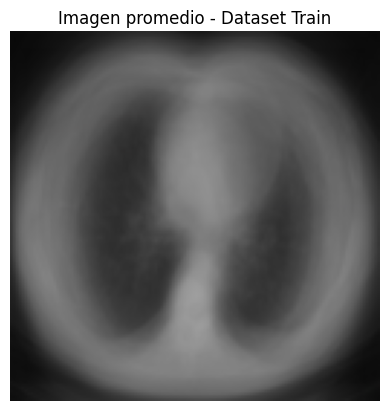

In [31]:
train_mean_all_classes = get_mean_image(dataloader=train_loader)

plt.imshow(train_mean_all_classes, vmin=0, vmax=255, cmap='Greys_r')
plt.title("Imagen promedio - Dataset Train")
plt.axis('off')
plt.show()

Se grafica a continuación la imagen promedio de la clase `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` del dataset de `train`.

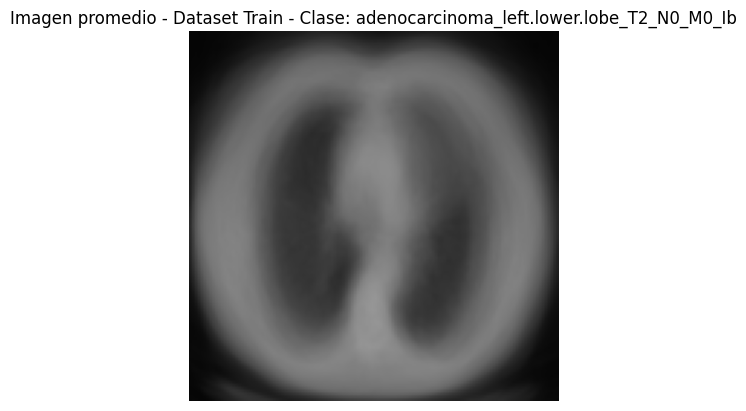

In [32]:
train_mean_0 = get_mean_image(dataloader=train_loader, labels_to_show=[0])

plt.imshow(train_mean_0, vmin=0, vmax=255, cmap='Greys_r')
plt.title(f"Imagen promedio - Dataset Train - Clase: {train_data.classes[0]}")
plt.axis('off')
plt.show()

Se grafica a continuación la imagen promedio de la clase `large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa` del dataset de `train`.

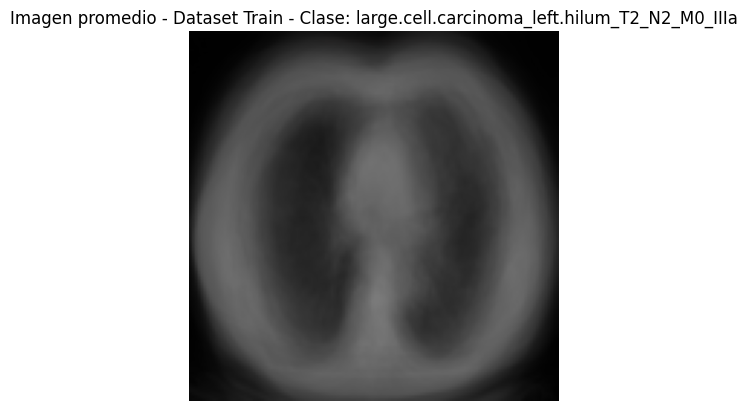

In [33]:
train_mean_1 = get_mean_image(dataloader=train_loader, labels_to_show=[1])

plt.imshow(train_mean_1, vmin=0, vmax=255, cmap='Greys_r')
plt.title(f"Imagen promedio - Dataset Train - Clase: {train_data.classes[1]}")
plt.axis('off')
plt.show()

Se grafica a continuación la imagen promedio de la clase `Normal` del dataset de `train`.

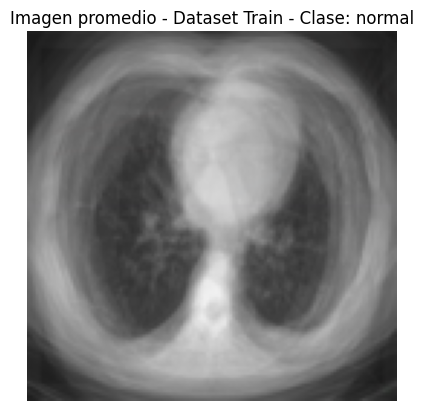

In [34]:
train_mean_2 = get_mean_image(dataloader=train_loader, labels_to_show=[2])

plt.imshow(train_mean_2, vmin=0, vmax=255, cmap='Greys_r')
plt.title(f"Imagen promedio - Dataset Train - Clase: {train_data.classes[2]}")
plt.axis('off')
plt.show()

Se grafica a continuación la imagen promedio de la clase `squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa` del dataset de `train`.

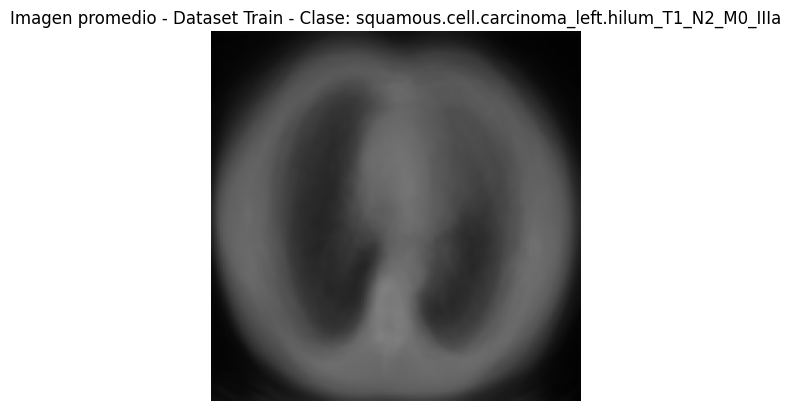

In [35]:
train_mean_3 = get_mean_image(dataloader=train_loader, labels_to_show=[3])

plt.imshow(train_mean_3, vmin=0, vmax=255, cmap='Greys_r')
plt.title(f"Imagen promedio - Dataset Train - Clase: {train_data.classes[3]}")
plt.axis('off')
plt.show()

Diferencia entre las imágenes promedio de la clase `Normal` y la clase `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` del dataset `train`.

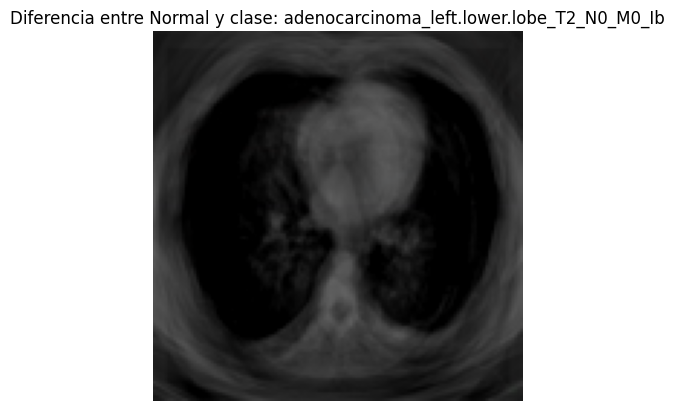

In [36]:
contrast_mean_2_0 = train_mean_2 - train_mean_0

plt.imshow(contrast_mean_2_0, cmap='bwr')
plt.title(f"Diferencia entre Normal y clase: {train_data.classes[0]}")
plt.axis('off')
plt.show()

Diferencia entre las imágenes promedio de la clase `Normal` y la clase `large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa` del dataset `train`.

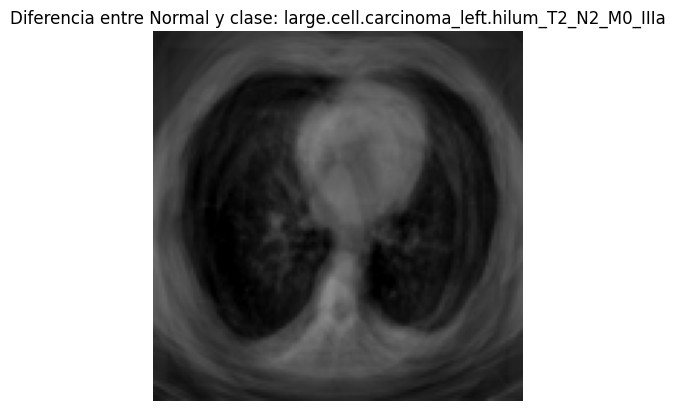

In [37]:
contrast_mean_2_1 = train_mean_2 - train_mean_1

plt.imshow(contrast_mean_2_1, cmap='bwr')
plt.title(f"Diferencia entre Normal y clase: {train_data.classes[1]}")
plt.axis('off')
plt.show()

Diferencia entre las imágenes promedio de la clase `Normal` y la clase `squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa` del dataset `train`.

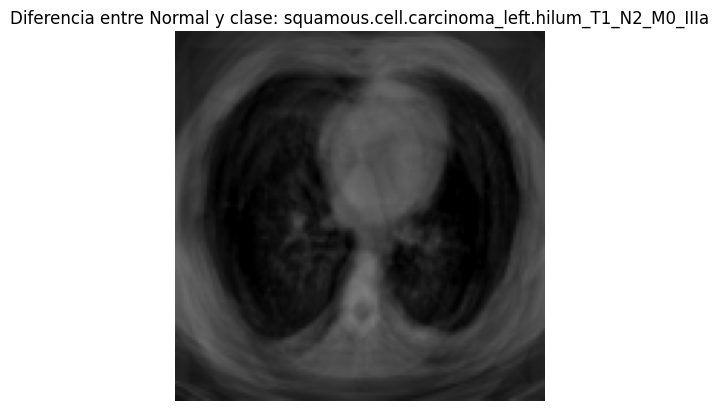

In [38]:
contrast_mean_2_3 = train_mean_2 - train_mean_3

plt.imshow(contrast_mean_2_3, cmap='bwr')
plt.title(f"Diferencia entre Normal y clase: {train_data.classes[3]}")
plt.axis('off')
plt.show()

En esta sección se hicieron dos tipos de *pruebas*:

1. Gráfico de la imagen promedio de cada clase del dataset de `train`.
1. Gráfico de la diferencia de la imagen promedio de la clase `Normal` respecto a la imagen promedio del resto de las clases, también del dataset de `train`.

La primer prueba nos permitió obtener una representación de como se ven, en promedio, las imágenes de cada clase en `train`. Si bien todas estas representaciones son importanes, la que más nos interesa es la de la clase `Normal`, ya que al no presentar *enfermedades*, si la comparamos con el resto podemos obtener algunas representaciones promedio de las mismas.

Esto último se realiza en la segunda prueba, en donde "restamos" la imagen promedio de la clase `Normal` con la imagen promedio de las demás enfermedades. Si bien a simple vista se pueden observar diferencias en las imágenes (más que nada del contraste de las mismas), el resultado obtenido no es el esperado, ya que no tenemos esas regions/zonas de interés resaltado. Aunque esto también puede deberse a nuestra falta de conocimiento dentro del área de estudio de medicina.

### PCA en imágenes

En esta sección se implementa la técnica de `PCA` en imágenes, o `Eigenfaces/Eigenimages`.

Ésta nos permitirá visualizar mejor a los componentes que mejor describen a cada clase de estudio.

Algunos de los beneficios que nos dará ésta implementación incluyen:
- Mejor visualización de los componentes que mejor describen a las clases de estudio.
- Reducción del **ruido** en las imágenes.
- Eliminar información **redundante**.

En particular, nos enfocaremos en el dataset de `train`.

Fuentes:
- [Principal Component Analysis in Medical Image Processing - A study](https://www.researchgate.net/profile/Mohammed-Abdel-Megeed-Mohammed-Salem/publication/272576742_Principal_Component_Analysis_in_Medical_Image_Processing_A_Study/links/55872e6308ae7bc2f44d31d2/Principal-Component-Analysis-in-Medical-Image-Processing-A-Study.pdf).
- [Principal Component Analysis on Computed Tomography Imaging for enhanced disease detection and diagnosis](https://www.researchgate.net/publication/388564222_Principal_Component_Analysis_on_Computed_Tomography_Imaging_for_enhanced_disease_detection_and_diagnosis#:~:text=Abstract,while%20discarding%20the%20irrelevant%20information.).
- [Exploratory Data Analysis Ideas for Image Classification](https://towardsdatascience.com/exploratory-data-analysis-ideas-for-image-classification-d3fc6bbfb2d2/).
- [PCA (Principal Components Analysis) applied to images of faces](https://medium.com/@sebastiannorena/pca-principal-components-analysis-applied-to-images-of-faces-d2fc2c083371).

In [39]:
def plot_eigenimages(dataloader: DataLoader,
                     n_components: float = 0.8,
                     title: str = "PCA - Dataloader",
                     classes_to_plot: list = [0, 1, 2, 3],
                     height: int = 128,
                     width: int = 128,
                     max_components_to_show: int = 10) -> PCA:
  """
  Función que grafica y devuelve PCA en imágenes.

  Args:
    dataloader (DataLoader): loader del set de imágenes.
    n_components (float): Porcentaje de variabilidad que se desea capturar.
      Representado con número flotante. Por defecto es 0.8.
    title (str): Título de la imagen a mostrar.
    classes_to_plot (title): Listado de clases a graficar, representados por
      su número de label.
    height (int): Altura de las imágenes. Por defecto es 128.
    width (int): Ancho de las imágenes. Por defecto es 128.
    max_components_to_show (int): Cantidad máxima de componentes a mostrar.
      Por defecto es 10.
  """
  grayscale_transform = transforms.Grayscale(num_output_channels=1)

  images_df = pd.DataFrame([])
  for image, label in dataloader:
    if label in classes_to_plot:
      image_gray = pd.Series(grayscale_transform(image).squeeze().flatten())
      images_df = pd.concat([images_df, image_gray.to_frame().T],
                            ignore_index=True)

  images_pca = PCA(n_components=n_components)
  images_pca.fit(images_df)

  nrows = math.ceil(min(len(images_pca.components_), max_components_to_show)/10)
  fig, axes = plt.subplots(nrows,10,figsize=(20,10),
    subplot_kw={"xticks":[], "yticks":[]},
    gridspec_kw=dict(hspace=0.01, wspace=0.01))
  fig.suptitle(title)

  for i, ax in enumerate(axes.flat):
    if i < images_pca.components_.shape[0]:
      ax.imshow(images_pca.components_[i].reshape(width, height),cmap="gray")
      title = f"Var: {images_pca.explained_variance_ratio_[i]*100:.4f}%"
      ax.set_title(title)
    else:
      ax.imshow(np.zeros(width * height).reshape(width, height),cmap="gray")

  return images_pca

Comenzamos graficando las componentes que capturan el $80\%$ de la variabilidad de la clase `Normal` en el dataset de `train`.

En este caso, se obtienen $8$ componentes, donde las componentes que mayor variabilidad capturan tienen el $31.85\%$ y el $19.96\%$ respectivamente.

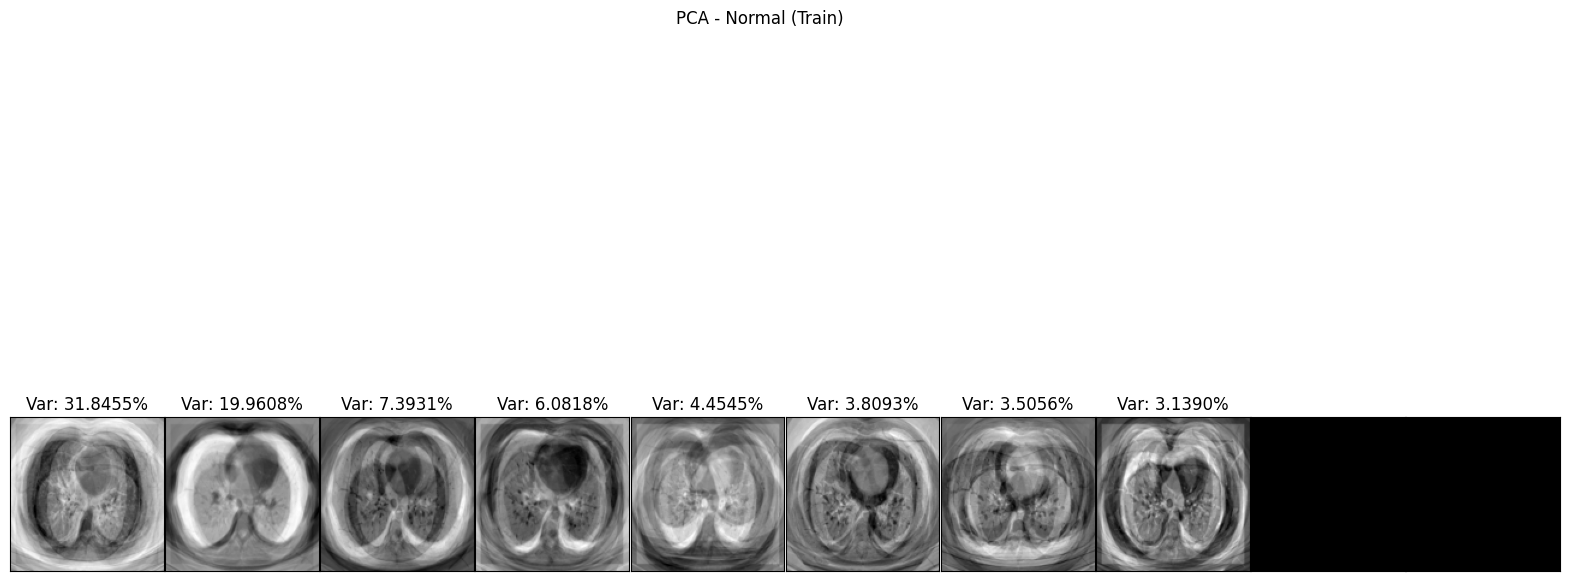

In [40]:
pca_clase_2 = plot_eigenimages(dataloader=train_loader, classes_to_plot = [2], title="PCA - Normal (Train)")

Se grafican a continuación las primeras $10$ componentes que capturan el $80\%$ de la variabilidad de la clase `Adenocarcinoma Left` (*adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib*) del dataset de `train`.

Las que mayor variabilidad capturan tienen el $32.15\%$ y el $9.69\%$ respectivamente.

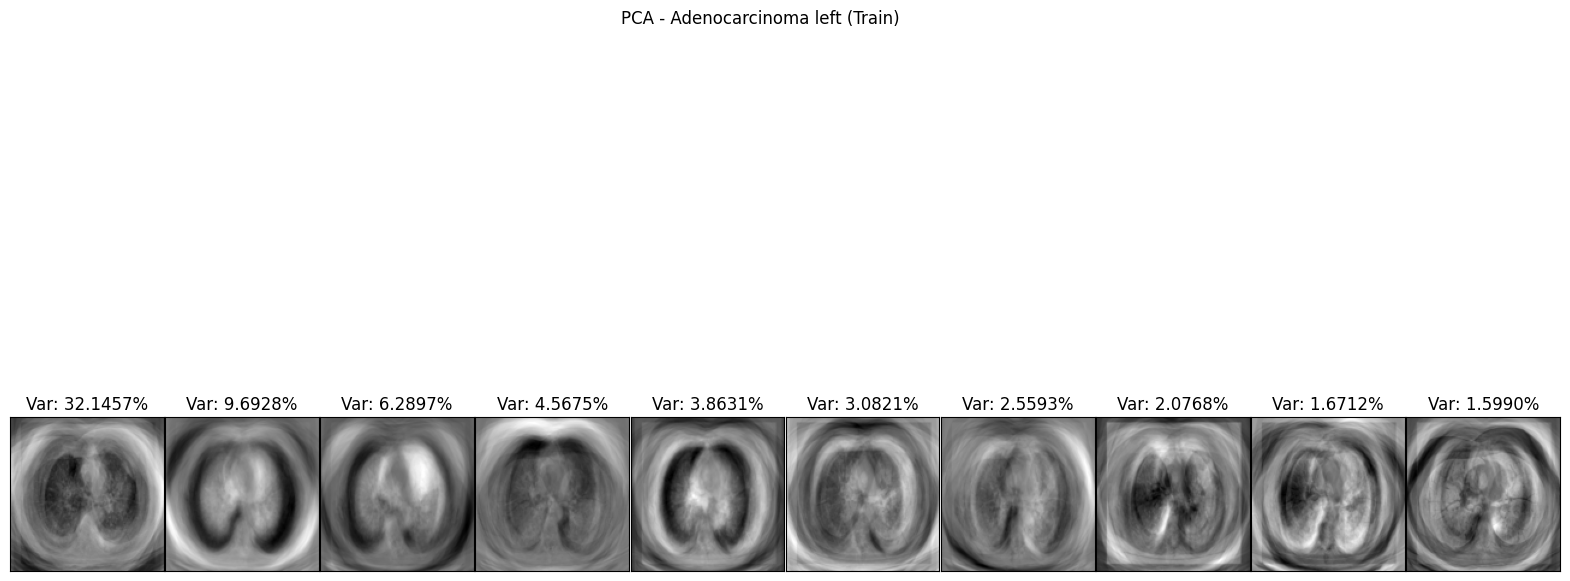

In [41]:
pca_clase_0 = plot_eigenimages(dataloader=train_loader, classes_to_plot = [0], title="PCA - Adenocarcinoma left (Train)")

Se grafican a continuación las primeras $10$ componentes que capturan el $80\%$ de la variabilidad de la clase `Large Cell Carcinoma Left` (*large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa*) del dataset de `train`.

Las que mayor variabilidad capturan tienen el $27.07\%$ y el $9.19\%$ respectivamente.

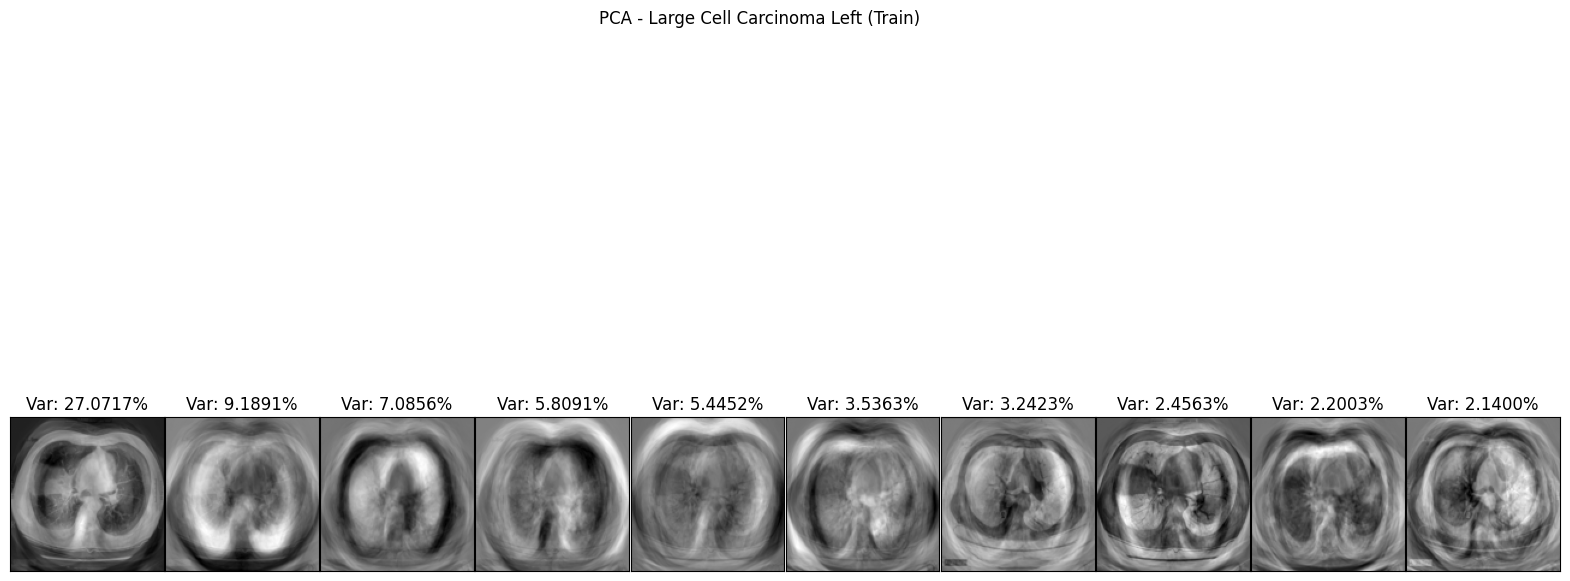

In [42]:
pca_clase_1 = plot_eigenimages(dataloader=train_loader, classes_to_plot = [1], title="PCA - Large Cell Carcinoma Left (Train)")

Finalmente se grafican las primeras $10$ componentes que capturan el $80\%$ de la variabilidad de la clase `Squamous cell carcinoma left` (*squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa*) del dataset de `train`.

Las que mayor variabilidad capturan tienen el $27.67\%$ y el $8.68\%$ respectivamente.

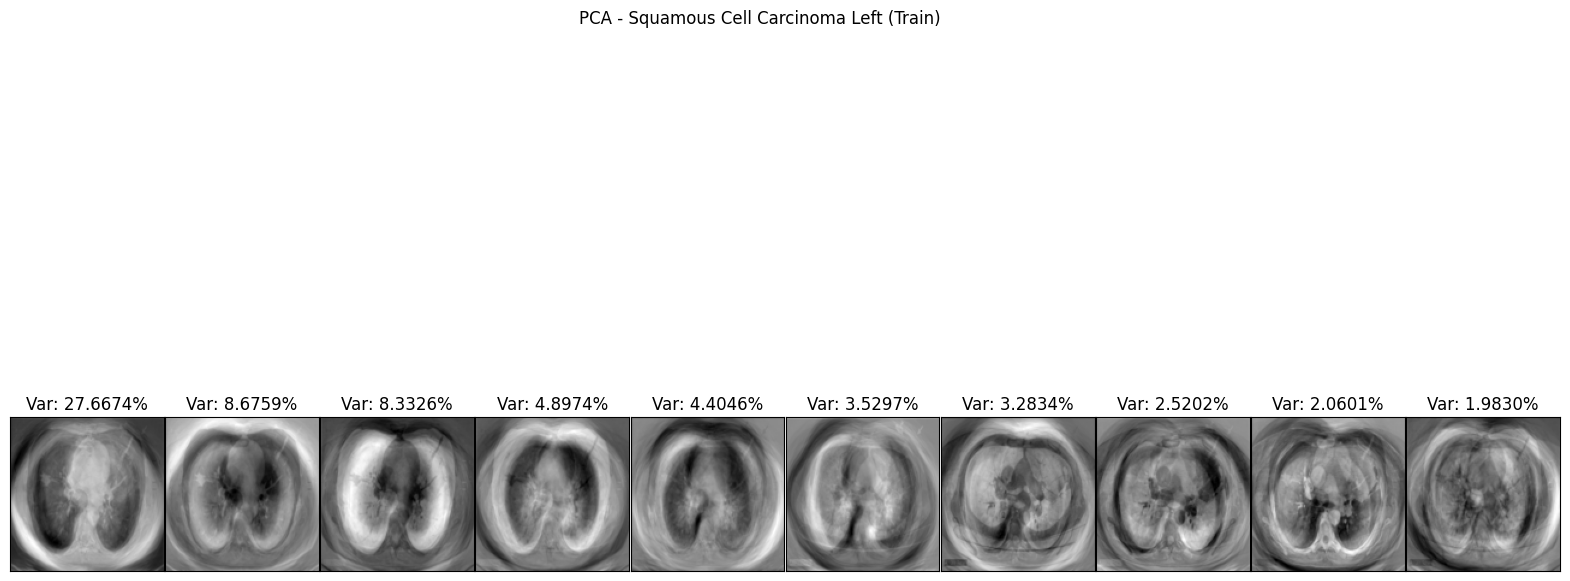

In [43]:
pca_clase_3 = plot_eigenimages(dataloader=train_loader, classes_to_plot = [3], title="PCA - Squamous Cell Carcinoma Left (Train)")

A partir de las operaciones anteriores se obtuvieron las componentes que mayor variabilidad capturan en las imágenes de cada clase.

En particular, las primeras componentes de cada clases capturan entre $27.07\%$ y $32.15\%$ de variabilidad.

Gráficamente, nos muestran una representación libre de ruido y de información redundante de las imágenes del dataset de `train`.

### Análisis de Blur (difuminado)

En esta sección se analiza el dataset de `train` a fin de determinar si las imágenes de éste están difuminadas o no (blur).

Que el dataset presente imágenes con difuminado podría ser beneficioso a la hora de entrenar un modelo de Deep Learning, ya que esto permite al modelo generalizar mejor.

Por este motivo, se comienza analizando si las imágenes tienen blur o no, mediante el uso del método laplaciano o [Varianza Laplaciana](https://www.geeksforgeeks.org/computer-vision/how-to-check-for-blurry-images-in-your-dataset-using-the-laplacian-method/). En particular, haremos uso de la función [Laplacian](https://docs.opencv.org/3.4/d5/db5/tutorial_laplace_operator.html) de `OpenCV`.

In [44]:
def get_laplacian_variance(tensor: torch.Tensor):
  """
  Dada una imagen en forma de tensor, devuelve la varianza del laplaciano.
  More info: https://www.geeksforgeeks.org/computer-vision/how-to-check-for-blurry-images-in-your-dataset-using-the-laplacian-method/
  """
  shapes = tensor.shape

  if len(shapes) > 3:
    tensor = tensor.reshape(shapes[1], shapes[2], shapes[3])

  np_img = tensor.numpy().transpose(1, 2, 0)
  np_img = (np_img * 255).astype(np.uint8)
  grayscale_image = cv2.cvtColor(np_img, cv2.COLOR_RGB2GRAY)
  laplacian_var = cv2.Laplacian(grayscale_image, cv2.CV_64F).var()

  return laplacian_var

Obtenemos los valores de varianza del laplaciano de cada imagen del dataset de `train`.

In [45]:
laplacian_variances = []
for img, lbl in train_loader:
  lp = get_laplacian_variance(img)
  laplacian_variances.append(lp)

Graficamos los valores obtenidos en un histograma, utilizando $10$ bins.

Se observa que la mayoría de las imágenes se encuentran en los tres primeros bins, definidos por los siguientes rangos:

1. Bin 1 -> [$140.149$, $450.221$] -> $145$ imágenes.
1. Bin 2 -> [$450.221$, $760.294$] -> $224$ imágenes.
1. Bin 3 -> [$760.294$, $1070.366$] -> $78$ imágenes

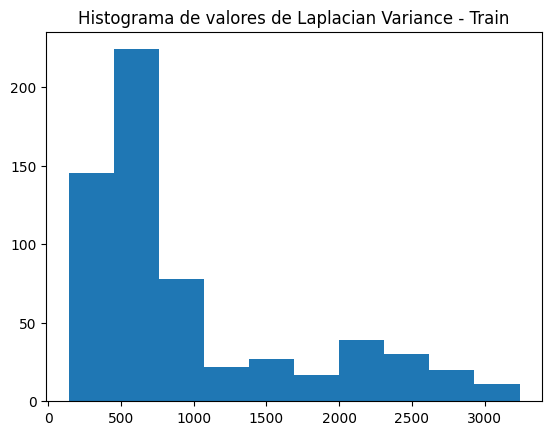

In [46]:
n, bins, patches = plt.hist(laplacian_variances, bins=10)
plt.title("Histograma de valores de Laplacian Variance - Train")
plt.show()

Cantidad de imágenes por bins:

In [47]:
n

array([145., 224.,  78.,  22.,  27.,  17.,  39.,  30.,  20.,  11.])

Rango de bins:

In [48]:
bins

array([ 140.14899349,  450.22127012,  760.29354675, 1070.36582337,
       1380.4381    , 1690.51037662, 2000.58265325, 2310.65492988,
       2620.7272065 , 2930.79948313, 3240.87175976])

A fin de determinar un `threshold` o límite de `laplacian variance` para determinar si una imagen está o no borrosa, vamos a analizar imágenes de los dos primeros bins, a fin de si estas están borrosas o no.

**NOTA**: un valor relativamente bajo del `laplacian variance` indica que la imagen está borrosa.

En caso de no encontrar casos positivos (imágenes borrosas), podemos decir que el dataset (o por lo menos la mayoría de las imágenes en `train`) NO están borrosas. Además, no será necesario analizar el resto de los bins, ya que los valores del laplaciano son mayores.

En caso de SI encontrar casos positivos en el primer bin, pero NO en el segundo, definiremos nuestro límite en función de los propios límites de cada bin.

En caso de SI encontrar casos positivos en ambos bins, deberemos agregar el tercer bin al análisis; y así sucesivamente con el resto de los bins.

In [49]:
bin_1_imgs = []
bin_2_imgs = []

laplacian_variances = []
for img, lbl in train_loader:
  lp = get_laplacian_variance(img)

  if lp <= 140.14899349:
    bin_1_imgs.append(img)

  if lp > 140.14899349 and lp <= 450.22127012:
    bin_1_imgs.append(img)

  if lp > 450.22127012 and lp <= 760.29354675:
    bin_2_imgs.append(img)

In [50]:
# Validamos que la cantidad de elementos en cada array corresponda a la cantidad de elementos por bin
len_b1 = len(bin_1_imgs)
len_b2 = len(bin_2_imgs)

print(f"Cantidad de elementos en el primer bin: {len_b1}")
print(f"Cantidad de elementos en el segundo bin: {len_b2}")

Cantidad de elementos en el primer bin: 145
Cantidad de elementos en el segundo bin: 224


In [51]:
def print_n_images_from_array(img_list: list, num_images: int = 5,
                              width: int = 128, height: int = 128,
                              channels: int = 3, title: str = "Imgs"):
  """
  Imprime N imágenes de un array de tensores que representan imágenes.

  Args:
    img_list (list): Lista de imágenes, representadas por tensores.
    num_images (int): Cantidad de imágenes a mostrar en una sola fila.
      Por defecto es 5.
    width (int): Ancho de la imagen. Por defecto es 128.
    height (int): Alto de la imagen. Por defecto es 128.
    channels (int): Cantidad de canales en la imagen. Por defecto es 3.
    title (str): Título del gráfico.
  """
  fig, axes = plt.subplots(nrows=1, ncols=num_images, figsize=(15, 3))
  fig.suptitle(title)
  len_ = len(img_list)
  for i in range(num_images):
    idx = random.randint(0, len_ - 1)
    axes[i].imshow(img_list[idx].reshape(channels, width, height).numpy().transpose(1, 2, 0))
    axes[i].axis('off')

#### Se muestran a continuación $5$ imágenes elegidas ***al azar*** correspondientes al Bin 1 y al Bin 2.

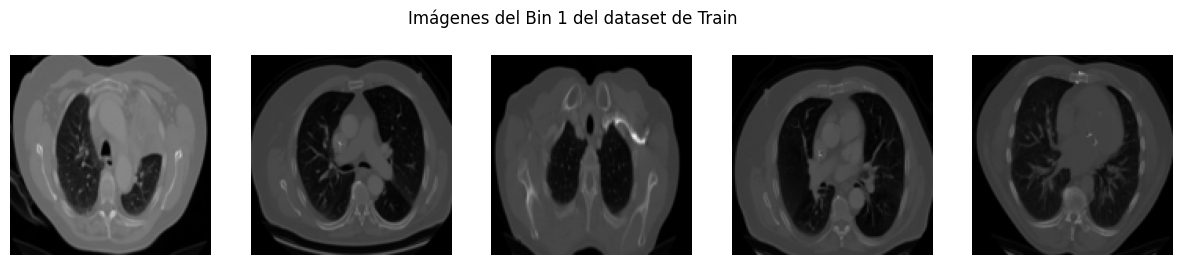

In [52]:
print_n_images_from_array(img_list=bin_1_imgs, title="Imágenes del Bin 1 del dataset de Train")

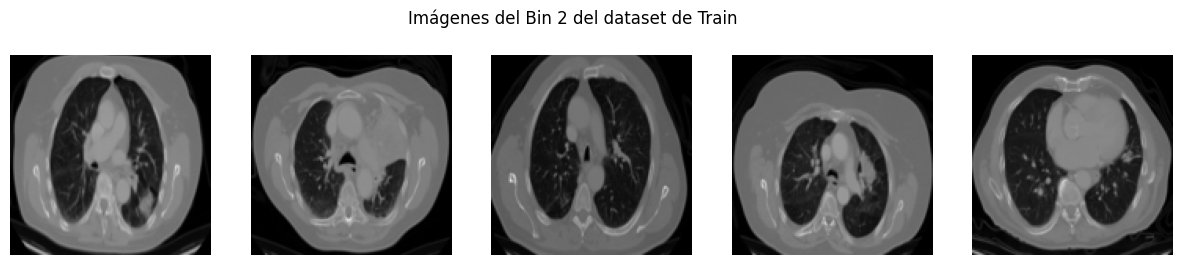

In [53]:
print_n_images_from_array(img_list=bin_2_imgs, title="Imágenes del Bin 2 del dataset de Train")

Tanto en las imágenes del Bin 1 y Bin 2 del dataset de NO se observan casos *difuminados* o *con blur*.

Si bien a la hora de utilizar imágenes de dataset se busca que estas no tengan errores o problemas de ruido, a la hora de ***entrenar modelos*** podría llegar ser beneficioso que estas tengan cierto *blur*, a fin de permitir que el modelo *generalice* mejor y de esta manera se evite el ***overfitting***.

Por esto último, podría ser beneficioso aplicar técnicas como desenfoque gaussiano o *Gaussian Blur* en el dataset mediante la transformación [GaussianBlur](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.GaussianBlur.html).

### Cálculo de Media y Desviación Estándar para Normalización

Antes de definir las transformaciones finales y el pipeline de aumentación de datos, es una práctica fundamental calcular los estadísticos del conjunto de entrenamiento. Específicamente, necesitamos la media y la desviación estándar por canal.

Estos valores se utilizarán para la normalización de las imágenes. La normalización (restar la media y dividir por la desviación estándar) asegura que los datos de entrada al modelo tengan una distribución centrada en cero y con varianza unitaria, lo cual es crítico para la estabilidad del entrenamiento y la velocidad de convergencia de redes profundas (como las vistas en la "Clase 2", ej. ResNet, VGG19).

Para este cálculo, se utiliza el train_data (con basic_transform que ya aplica ToTensor()) y se itera sobre él.

In [54]:
# Para el cálculo de estadísticos, es preferible no mezclar los datos (shuffle=False)
# Se utiliza el train_data que ya definimos con ToTensor()
train_loader_for_stats = DataLoader(train_data, batch_size=64, shuffle=False)

def get_mean_std(loader):
    """
    Calcula la media y la desviación estándar por canal (RGB) de un
    conjunto de datos cargado por un DataLoader.
    """
    # Inicialización de variables
    channels_sum, channels_sqrd_sum, num_batches = 0, 0, 0

    print("Calculando media y std del dataset de train...")
    for data, _ in loader:
        # data tiene shape [batch_size, channels, height, width]
        # Se calcula la media y la media de los cuadrados por canal (dim 1)
        # sobre las dimensiones espaciales (dim 2, 3) y el batch (dim 0)
        channels_sum += torch.mean(data, dim=[0, 2, 3])
        channels_sqrd_sum += torch.mean(data**2, dim=[0, 2, 3])
        num_batches += 1

    # Media final
    mean = channels_sum / num_batches

    # Varianza = E[X^2] - (E[X])^2
    # Std = sqrt(Varianza)
    std = (channels_sqrd_sum / num_batches - mean**2)**0.5

    return mean, std

# Ejecutamos el cálculo
dataset_mean, dataset_std = get_mean_std(train_loader_for_stats)

print(f"\nCálculo finalizado.")
print(f"Media del dataset (por canal): {dataset_mean}")
print(f"Desviación Estándar del dataset (por canal): {dataset_std}")

Calculando media y std del dataset de train...

Cálculo finalizado.
Media del dataset (por canal): tensor([0.3218, 0.3218, 0.3218])
Desviación Estándar del dataset (por canal): tensor([0.2606, 0.2606, 0.2606])


Con los tensores dataset_mean y dataset_std calculados, ahora poseemos los estadísticos específicos de nuestro dataset de entrenamiento

### Definición de Transformaciones y Data Augmentation

Continuando con las observaciones del análisis exploratorio, se identificaron dos puntos clave:

1. La variabilidad de dimensiones en las imágenes (ej. alto de 168 a 1200 en train), lo que hace mandatorio un redimensionamiento (Resize).

2. La presencia de imágenes con blur, lo que sugiere que aplicar un desenfoque (como el desenfoque gaussiano) de forma aleatoria podría ser beneficioso para que el modelo generalice mejor y se evite el overfitting.

Procedemos a implementar un pipeline de transformaciones que aborde estos puntos:

In [55]:
# Se definen las transformaciones para validación y test
# (Solo redimensionar, pasar a tensor y normalizar con nuestros estadísticos)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)), # Tamaño estándar para arquitecturas comunes (ej. 224x224)
    transforms.ToTensor(),
    transforms.Normalize(mean=dataset_mean, std=dataset_std)
])

# Se definen las transformaciones para el set de entrenamiento
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    # --- Implementación de la hipótesis del EDA ---
    # Aplicamos desenfoque gaussiano aleatoriamente (en 50% de las imágenes)
    # Se usa un kernel de tamaño variable para simular distintos tipos de blur.
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5.0))
    ], p=0.5),

    # --- Augmentations estándar ---
    transforms.RandomHorizontalFlip(p=0.5), # Giro horizontal aleatorio
    transforms.RandomRotation(15), # Rotación aleatoria de +/- 15 grados

    transforms.ToTensor(),
    transforms.Normalize(mean=dataset_mean, std=dataset_std) # Normalización
])

# Se recargan los datasets utilizando estas nuevas transformaciones
train_data_aug = datasets.ImageFolder(root=DATASET_TRAIN, transform=train_transform)
validation_data_aug = datasets.ImageFolder(root=DATASET_VALID, transform=val_test_transform)

print("Datasets recargados con las nuevas transformaciones (train_transform y val_test_transform).")

Datasets recargados con las nuevas transformaciones (train_transform y val_test_transform).


### Visualización del Efecto de Augmentation

Finalmente, para validar visualmente que las transformaciones de Data Augmentation se están aplicando como se espera (especialmente el GaussianBlur aleatorio), se tomará una imagen del dataset de train y se le aplicará la transformación train_transform múltiples veces.

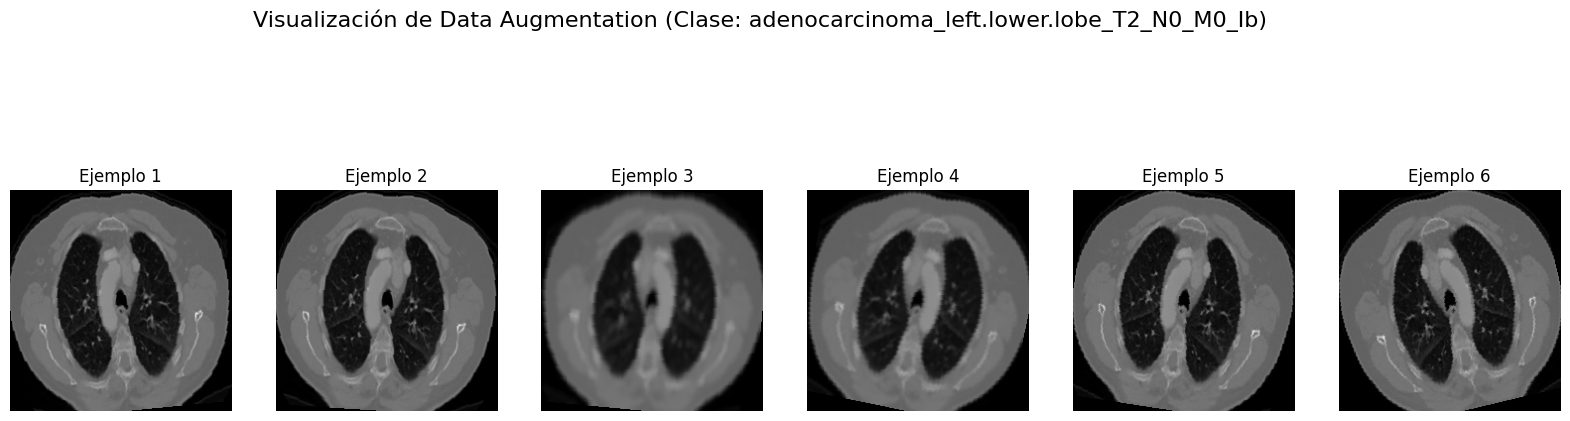

In [56]:
def show_augmentations_preview(dataset: ImageFolder, num_images: int = 6):
    """
    Muestra una imagen del dataset con 'num_images' transformaciones
    aleatorias aplicadas. Incluye la des-normalización para poder
    visualizar correctamente con matplotlib.
    """
    fig, axes = plt.subplots(1, num_images, figsize=(20, 6))

    # Tomamos la primera imagen como ejemplo
    img_path, label = dataset.samples[0]

    # Se necesita invertir la normalización para visualización
    mean = np.array(dataset_mean)
    std = np.array(dataset_std)

    for i in range(num_images):
        # Al hacer __getitem__, ImageFolder aplica el 'transform'
        aug_img_tensor, _ = dataset[0]

        # Invertir Normalización y ToTensor
        # (C, H, W) -> (H, W, C)
        aug_img = aug_img_tensor.permute(1, 2, 0).numpy()
        aug_img = std * aug_img + mean # Des-normalizar
        aug_img = np.clip(aug_img, 0, 1) # Asegurar rango [0, 1]

        axes[i].imshow(aug_img)
        axes[i].set_title(f"Ejemplo {i+1}")
        axes[i].axis('off')

    plt.suptitle(f"Visualización de Data Augmentation (Clase: {dataset.classes[label]})", fontsize=16)
    plt.show()

# Visualizamos 6 ejemplos de aumentación sobre la primera imagen de train
show_augmentations_preview(train_data_aug, num_images=6)

Como se observa en la visualización, las transformaciones se aplican correctamente. Cada imagen es una versión diferente de la original, presentando rotaciones, giros y, notablemente, en algunas de ellas se aplica el desenfoque gaussiano (como se definió con p=0.5).

## Baseline

### Data Augmentation

Comenzamos aplicando el `data augmentation` definido en el paso anterior (`EDA - Definición de Transformaciones y Data Augmentation`).

***TO-DO***: repasar cada uno de los augmentation que hacemos, ***justificando*** el por qué.

In [96]:
train_data = datasets.ImageFolder(root=DATASET_TRAIN, transform=train_transform)
validation_data = datasets.ImageFolder(root=DATASET_VALID, transform=val_test_transform)
test_data = datasets.ImageFolder(root=DATASET_TEST, transform=val_test_transform)

Se crean a continuación los dataloaders de `train`, `test` y `validation`, utilizando un ***Batch Size*** de $32$. El único data loader con `shuffle = True` es el de `train`.

In [97]:
BATCH_SIZE = 32

In [98]:
train_loader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)
validation_loader = DataLoader(dataset=validation_data, batch_size=BATCH_SIZE, shuffle=False)

### Imports

In [99]:
!pip install torchmetrics

In [135]:
from torchvision.models import resnet18, ResNet18_Weights
import torchsummary
import torchmetrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Función para train-test loop

***TO-DO***:

- Agregar breve descripción del loop siguiente.
- Si hay tiempo, agregar Early Stopping (con patience).

In [136]:
def train_eval_loop(model: any, optimizer, criterion, metric,
                    data: dict, epochs: int = 100, tb_writer: dict = None):
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  train_loader = data["train"]
  valid_loader = data["valid"]

  if tb_writer:
    train_writer = tb_writer["train"]
    valid_writer = tb_writer["valid"]

    train_writer.add_graph(model, torch.zeros((1, data["image_channels"],
                                                data["image_width"],
                                                data["image_height"])))
    valid_writer.add_graph(model, torch.zeros((1, data["image_channels"],
                                                data["image_width"],
                                                data["image_height"])))
  model.to(device)
  metric.to(device)

  train_loss = []
  train_metric = []
  valid_loss = []
  valid_metric = []

  for epoch in range(epochs):

    ####################  TRAIN  ####################
    model.train()

    epoch_train_loss = 0.0
    epoch_train_metric = 0.0

    for train_data, train_target in train_loader:

      train_data = train_data.to(device)
      train_target = train_target.to(device)

      optimizer.zero_grad()
      output = model(train_data.float())
      loss = criterion(output, train_target)
      epoch_train_loss += loss.item()
      loss.backward()
      optimizer.step()

      epoch_train_metric += metric(output, train_target).item()

    epoch_train_loss = epoch_train_loss / len(train_loader)
    epoch_train_metric = epoch_train_metric / len(train_loader)
    train_loss.append(epoch_train_loss)
    train_metric.append(epoch_train_metric)

    ####################  EVAL  ####################
    model.eval()

    epoch_valid_loss = 0.0
    epoch_valid_metric = 0.0

    # Labels y predicciones, para facilitar el cálculo de
    # matrices de confusión
    all_preds = torch.tensor([]).to(device)
    all_labels = torch.tensor([]).to(device)

    for valid_data, valid_target in valid_loader:
      valid_data = valid_data.to(device)
      valid_target = valid_target.to(device)

      output = model(valid_data.float())
      epoch_valid_loss += criterion(output, valid_target).item()
      epoch_valid_metric += metric(output, valid_target).item()

      # Labels y predicciones de cada época
      all_preds = torch.cat((all_preds, output))
      all_labels = torch.cat((all_labels, valid_target))

    epoch_valid_loss = epoch_valid_loss / len(valid_loader)
    epoch_valid_metric = epoch_valid_metric / len(valid_loader)
    valid_loss.append(epoch_valid_loss)
    valid_metric.append(epoch_valid_metric)

    print("Epoch: {}/{} - Train loss {:.6f} - Train Metric {:.6f} - Valid Loss {:.6f} - Valid Metric {:.6f}".format(
    epoch+1, epochs, epoch_train_loss, epoch_train_metric, epoch_valid_loss, epoch_valid_metric))

    if tb_writer:
      train_writer.add_scalar("loss", epoch_train_loss, epoch)
      valid_writer.add_scalar("loss", epoch_valid_loss, epoch)
      train_writer.add_scalar("metric", epoch_train_metric, epoch)
      valid_writer.add_scalar("metric", epoch_valid_metric, epoch)
      train_writer.flush()
      valid_writer.flush()

  history = {}
  history["train_loss"] = train_loss
  history["train_metric"] = train_metric
  history["valid_loss"] = valid_loss
  history["valid_metric"] = valid_metric
  history["labels_last_epoch"] = all_labels
  history["pred_last_epoch"] = all_preds

  return history

### Modelo para baseline

***TO-DO***

Explicar:
- Por qué utilizamos transfer learning?
- Por qué utilizamos ResNet18?
- `weights = ResNet18_Weights.IMAGENET1K_V1` (usamos los pesos finales de la red ResNet18).
- Por qué usamos `transforms = weigths.transforms()` y no las data augmentations definidas en `Data Augmentation`?

In [137]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
OUTPUTS = 4
CANT_CLASES = 4

In [138]:
weights = ResNet18_Weights.IMAGENET1K_V1
transforms = weights.transforms()

In [139]:
transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [140]:
train_transform

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomApply(
    p=0.5
    GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5.0))
)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=tensor([0.3218, 0.3218, 0.3218]), std=tensor([0.2606, 0.2606, 0.2606]))
)

In [141]:
resnet18_model = resnet18(weights=weights)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet18_model.to(device)

torchsummary.summary(resnet18_model, input_size=(IMG_CHANNELS, IMG_HEIGHT, IMG_WIDTH))
resnet18_model.modules

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

<bound method Module.modules of ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (layer2): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (downsample): Sequential(
        (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): BasicBlock(
      (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (layer3): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (downsample): Sequential(
        (0): Conv2d(128, 256, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): BasicBlock(
      (conv1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (layer4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (downsample): Sequential(
        (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(

***TO-DO***
- Explicar por qué es necesario el `param.requires_grad = False` (básicamente, es porque estamos haciendo transfer learning).
- Explicar las últimas dos líneas de la siguiente celda (Fully connected, con ciertas `in features` y $4$ outputs).

In [142]:
for param in resnet18_model.parameters():
    param.requires_grad = False

last_layer_in_features = resnet18_model.fc.in_features
resnet18_model.fc = torch.nn.Linear(in_features=last_layer_in_features, out_features=OUTPUTS)

In [143]:
last_layer_in_features

512

### Entrenamiento

***TO-DO***

- Por qué utilizamos Adam? (básicamente, es el mejor optimizador para estos casos. Buscar fuentes).
- Por qué utilizamos un `Learning Rate` bajo? (Recuerdo que era porque estábamos en las últimas capas de la red, al utilizar transfer learning. Buscar fuentes).
- Probar otros valores de `Learning Rate`.
- Por qué el Loss? (Porque estamos en clasificación de N clases, con N > 2. Buscar fuentes).

In [144]:
optimizer = torch.optim.Adam(resnet18_model.parameters(), lr=0.00001)
loss = torch.nn.CrossEntropyLoss()

***TO-DO --- VALIDAR***

- `Recall` es la métrica correcta? Buscar ejemplos/fuentes en donde recomienden esta métrica, SINO cambiarla.

In [145]:
metric = torchmetrics.Recall(task='multiclass', num_classes=CANT_CLASES)

***TO-DO --- VALIDAR***

- En el [notebook de la clase 2](https://colab.research.google.com/drive/1K_8MHHtgfpcBUmiTDTKF18Bx809CEvtT#scrollTo=n6ZbMLvyi_RD), cuando se definen los datasets de `cifar10_train_set` y `cifar10_test_set` utilizan los mismos transforms que se utilizan en el modelo base.
- Tenemos que hacer lo mismo???
- Detalle: al hacer esto, las métricas dan mejor.
  - Si usamos nuestras transformations, el recall en validation es de $0.375$ (aprox).
  - Si usamos las del modelo, el recall en validation es de $0.473$ (aprox).

In [146]:
# train_data = datasets.ImageFolder(root=DATASET_TRAIN, transform=transforms)
# validation_data = datasets.ImageFolder(root=DATASET_VALID, transform=transforms)
# test_data = datasets.ImageFolder(root=DATASET_TEST, transform=transforms)

# train_loader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
# test_loader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)
# validation_loader = DataLoader(dataset=validation_data, batch_size=BATCH_SIZE, shuffle=False)

In [147]:
data = {"train": train_loader, "valid": test_loader, "image_width": IMG_WIDTH, "image_height": IMG_HEIGHT}

***TO-DO***
- Por qué 20 epochs? Básicamente, porque es un baseline. Explicar mejor.

In [148]:
EPOCHS = 20

In [149]:
history = train_eval_loop(model=resnet18_model.to(device),
                          optimizer=optimizer,
                          criterion=loss,
                          metric=metric,
                          data=data,
                          epochs=EPOCHS,
                          tb_writer=None)

Epoch: 1/20 - Train loss 1.436378 - Train Metric 0.259375 - Valid Loss 1.311601 - Valid Metric 0.425000
Epoch: 2/20 - Train loss 1.433345 - Train Metric 0.274063 - Valid Loss 1.341188 - Valid Metric 0.384375
Epoch: 3/20 - Train loss 1.413113 - Train Metric 0.277813 - Valid Loss 1.373338 - Valid Metric 0.350000
Epoch: 4/20 - Train loss 1.410509 - Train Metric 0.298438 - Valid Loss 1.375290 - Valid Metric 0.325000
Epoch: 5/20 - Train loss 1.388452 - Train Metric 0.319688 - Valid Loss 1.376319 - Valid Metric 0.328125
Epoch: 6/20 - Train loss 1.388698 - Train Metric 0.307500 - Valid Loss 1.375798 - Valid Metric 0.340625
Epoch: 7/20 - Train loss 1.394776 - Train Metric 0.315313 - Valid Loss 1.372471 - Valid Metric 0.343750
Epoch: 8/20 - Train loss 1.387427 - Train Metric 0.308438 - Valid Loss 1.365759 - Valid Metric 0.356250
Epoch: 9/20 - Train loss 1.398481 - Train Metric 0.297500 - Valid Loss 1.359680 - Valid Metric 0.369329
Epoch: 10/20 - Train loss 1.383422 - Train Metric 0.300625 - Val

### Gráficos y métricas

***TO-DO***

- Explicar gráfico

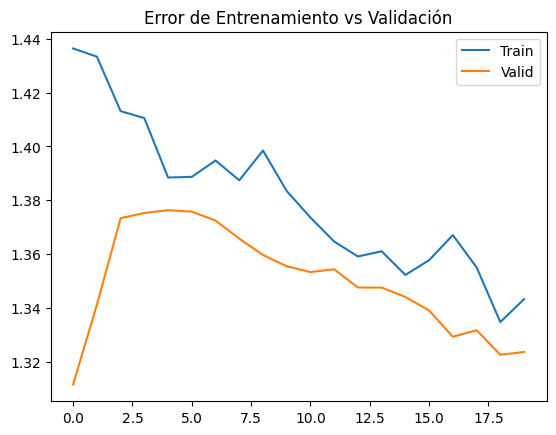

In [150]:
plt.plot(history["train_loss"])
plt.plot(history["valid_loss"])
plt.title("Error de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

***TO-DO***

- Explicar gráfico

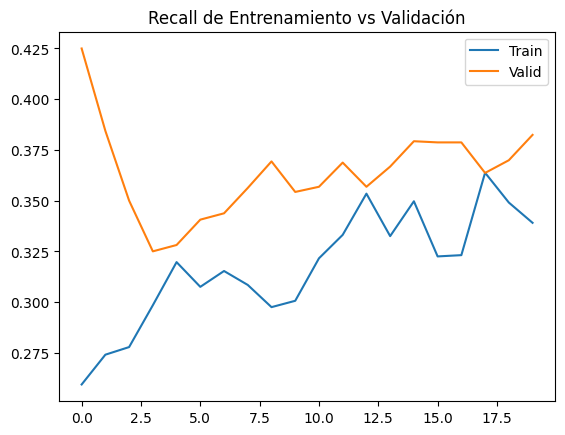

In [151]:
plt.plot(history["train_metric"])
plt.plot(history["valid_metric"])
plt.title("Recall de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

#### Classification Report

In [152]:
report = classification_report(y_true=history["labels_last_epoch"].cpu(), y_pred=history["pred_last_epoch"].argmax(dim=1).cpu(), target_names=train_data.classes)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [153]:
print(report)

                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.38      0.78      0.52       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.00      0.00      0.00        51
                                          normal       0.53      0.37      0.43        54
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.25      0.09      0.13        90

                                        accuracy                           0.39       315
                                       macro avg       0.29      0.31      0.27       315
                                    weighted avg       0.31      0.39      0.31       315



#### Matriz de confusión

In [154]:
cm = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()))

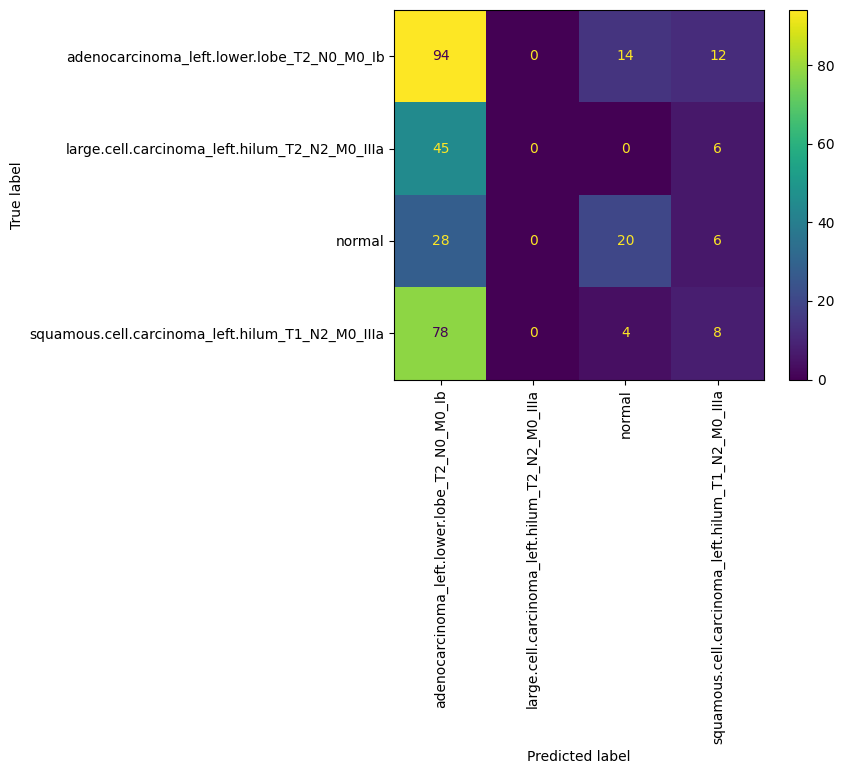

In [155]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_data.classes)
disp.plot()
disp.ax_.tick_params(axis='x', rotation=90)
plt.show()

#### Matriz de confusión Normalizada por Fila/Row

In [156]:
cm_normalized_by_row = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()), normalize='true')

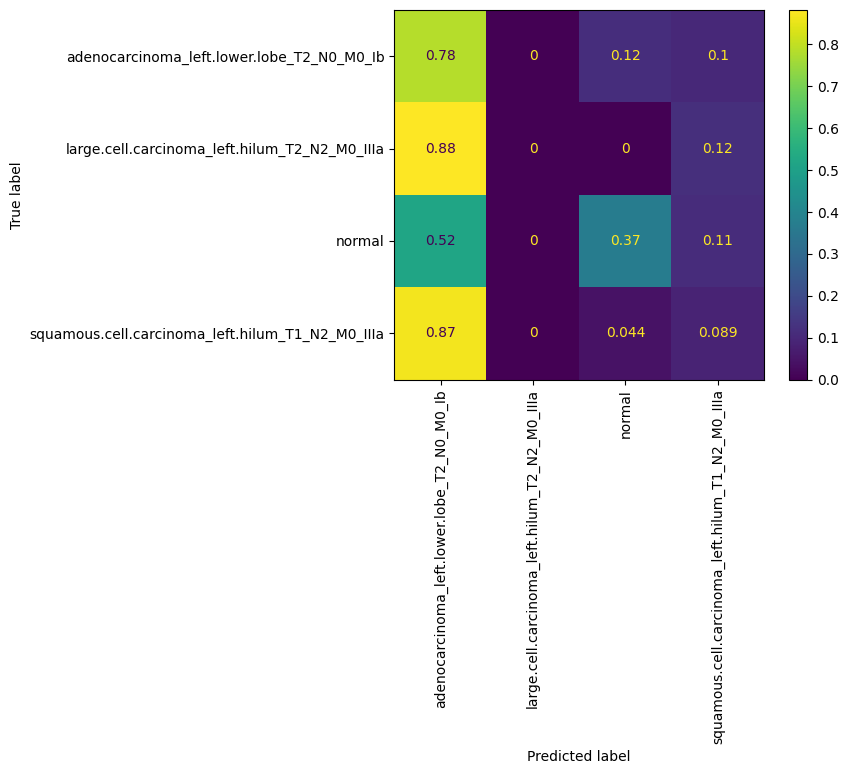

In [157]:
disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_by_row, display_labels=train_data.classes)
disp_normalized.plot()
disp_normalized.ax_.tick_params(axis='x', rotation=90)
plt.show()